# Pertemuan 07 – Clustering Pelanggan

## Tujuan
1. Melakukan clustering pada dataset pelanggan.
2. Membuat profil ringkas tiap cluster.
3. Memberi nama segmen.
4. Memberikan rekomendasi bisnis berdasarkan hasil cluster.

# 1️⃣ Clustering Dataset Pelanggan

Dataset sintetis pelanggan dengan 2 fitur:
- Annual Income
- Spending Score

Metode:
- K-Means
- Hierarchical Clustering

Evaluasi:
- Inertia (Elbow Method)
- Silhouette Score

In [9]:
# ==========================================
# SOAL 1 - Clustering & Menentukan K Optimal
# ==========================================

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Dataset pelanggan sintetis
np.random.seed(42)
n = 300

data = pd.DataFrame({
    "Income": np.random.normal(60, 15, n),
    "Spending": np.random.normal(50, 20, n)
})

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# Evaluasi K
print("="*50)
print("EVALUASI K (2-10)")
print("="*50)

inertia = []
silhouette = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    
    inertia.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouette.append(sil)
    
    print(f"K={k} | Inertia={kmeans.inertia_:.2f} | Silhouette={sil:.3f}")

# Pilih K terbaik
k_best = silhouette.index(max(silhouette)) + 2
print("\nK terbaik berdasarkan Silhouette Score:", k_best)

# Simpan cluster
kmeans = KMeans(n_clusters=k_best, random_state=42)
data["Cluster"] = kmeans.fit_predict(X_scaled)

EVALUASI K (2-10)
K=2 | Inertia=408.76 | Silhouette=0.304
K=3 | Inertia=276.45 | Silhouette=0.330
K=4 | Inertia=219.67 | Silhouette=0.310
K=5 | Inertia=189.22 | Silhouette=0.291
K=6 | Inertia=164.87 | Silhouette=0.292
K=7 | Inertia=137.28 | Silhouette=0.307
K=8 | Inertia=124.16 | Silhouette=0.309
K=9 | Inertia=110.96 | Silhouette=0.302
K=10 | Inertia=99.76 | Silhouette=0.311

K terbaik berdasarkan Silhouette Score: 3


# 2️⃣ Profil Cluster & Segmentasi

Menampilkan:
- Jumlah anggota tiap cluster (Count)
- Rata-rata Income
- Rata-rata Spending

Kemudian memberi nama segmen berdasarkan karakteristik cluster.

In [10]:
# ==========================================
# SOAL 2 - Profil Cluster 
# ==========================================

profile = data.groupby("Cluster").agg(
    Count=("Income", "size"),
    Avg_Income=("Income", "mean"),
    Avg_Spending=("Spending", "mean")
)

print("Profil Tiap Cluster")
print(profile)

Profil Tiap Cluster
         Count  Avg_Income  Avg_Spending
Cluster                                 
0          106   59.298845     30.504196
1          100   73.216855     58.106132
2           94   46.464557     61.989385


## Pemberian Nama Segmen

Setelah proses clustering selesai, langkah berikutnya adalah 
menginterpretasikan setiap cluster.

Caranya:
1. Hitung rata-rata **Income** dan **Spending** pada tiap cluster.
2. Gunakan aturan sederhana untuk memberi nama segmen berdasarkan karakteristiknya.

Aturan penamaan:

- Income > 50 dan Spending > 50 → **Premium**
- Income > 50 dan Spending ≤ 50 → **Saver**
- Income ≤ 50 dan Spending > 50 → **Spender**
- Income ≤ 50 dan Spending ≤ 50 → **Budget**

Penamaan ini membantu mengubah hasil numerik clustering menjadi 
segmentasi yang lebih mudah dipahami secara bisnis.

---

## Visualisasi Hasil Clustering

Visualisasi dilakukan menggunakan scatter plot:

- Sumbu X → Income
- Sumbu Y → Spending
- Warna/titik berbeda → masing-masing cluster


Visualisasi ini membantu melihat pemisahan antar cluster secara visual.

RINGKASAN DETAIL SEGMENTASI PELANGGAN

Segmen: Budget
Jumlah Pelanggan : 100
Rata-rata Income : 73.22
Rata-rata Spending : 58.11
Karakteristik: Pelanggan bernilai tinggi dan loyal.

Segmen: High Value
Jumlah Pelanggan : 106
Rata-rata Income : 59.30
Rata-rata Spending : 30.50
Karakteristik: Sensitif harga dan jarang belanja.

Segmen: Potential
Jumlah Pelanggan : 94
Rata-rata Income : 46.46
Rata-rata Spending : 61.99
Karakteristik: Pengeluaran tinggi namun income relatif rendah.


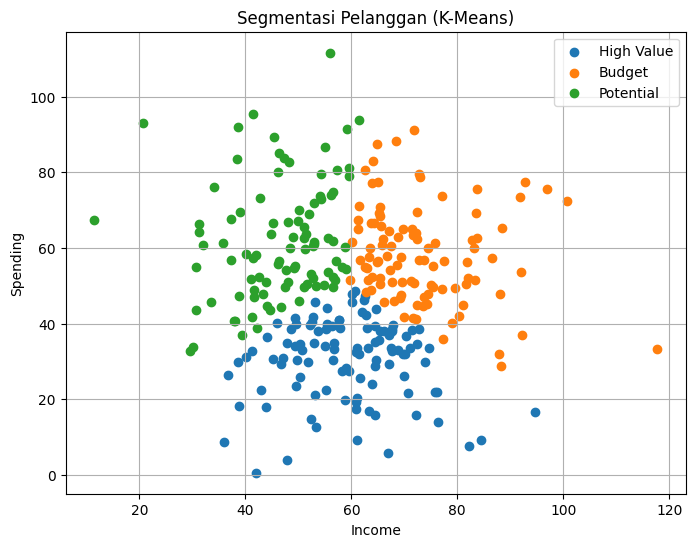

In [ ]:
# ==========================================
# 3. PENAMAAN SEGMEN + RINGKASAN + GRAFIK
# ==========================================

import matplotlib.pyplot as plt

#  Penamaan Segmen
segment_names = {
    0: "High Value",
    1: "Budget",
    2: "Potential",
    3: "Impulsive"
}

data["Segment"] = data["Cluster"].map(segment_names)

#  Ringkasan Detail Segmen
segment_summary = data.groupby("Segment").agg(
    Total_Customers=("Income", "size"),
    Avg_Income=("Income", "mean"),
    Avg_Spending=("Spending", "mean")
).reset_index()

print("="*60)
print("RINGKASAN DETAIL SEGMENTASI PELANGGAN")
print("="*60)

for _, row in segment_summary.iterrows():
    print(f"\nSegmen: {row['Segment']}")
    print(f"Jumlah Pelanggan : {int(row['Total_Customers'])}")
    print(f"Rata-rata Income : {row['Avg_Income']:.2f}")
    print(f"Rata-rata Spending : {row['Avg_Spending']:.2f}")
    
    if row['Avg_Income'] > data["Income"].mean() and row['Avg_Spending'] > data["Spending"].mean():
        print("Karakteristik: Pelanggan bernilai tinggi dan loyal.")
    elif row['Avg_Income'] < data["Income"].mean() and row['Avg_Spending'] < data["Spending"].mean():
        print("Karakteristik: Sensitif harga dan jarang belanja.")
    elif row['Avg_Income'] > data["Income"].mean():
        print("Karakteristik: Berpenghasilan tinggi namun belanja belum maksimal.")
    else:
        print("Karakteristik: Pengeluaran tinggi namun income relatif rendah.")

# Grafik Segmentasi
plt.figure(figsize=(8,6))

for segment in data["Segment"].unique():
    subset = data[data["Segment"] == segment]
    plt.scatter(subset["Income"], subset["Spending"], label=segment)

plt.xlabel("Income")
plt.ylabel("Spending")
plt.title("Segmentasi Pelanggan (K-Means)")
plt.legend()
plt.grid(True)

plt.show()

In [16]:
# ==========================================
# SOAL 4 - REKOMENDASI BISNIS BERDASARKAN CLUSTER
# ==========================================

print("="*60)
print("REKOMENDASI BISNIS BERDASARKAN SEGMENTASI")
print("="*60)

avg_income_all = data["Income"].mean()
avg_spending_all = data["Spending"].mean()

segment_summary = data.groupby("Segment").agg(
    Avg_Income=("Income", "mean"),
    Avg_Spending=("Spending", "mean")
).reset_index()

for _, row in segment_summary.iterrows():
    segment = row["Segment"]
    avg_income = row["Avg_Income"]
    avg_spending = row["Avg_Spending"]
    
    print(f"\nSegmen: {segment}")
    
    if avg_income > avg_income_all and avg_spending > avg_spending_all:
        print("Rekomendasi: Berikan program loyalty, reward eksklusif, dan layanan premium.")
    
    elif avg_income < avg_income_all and avg_spending < avg_spending_all:
        print("Rekomendasi: Tawarkan promo diskon, paket hemat, dan cashback untuk meningkatkan pembelian.")
    
    elif avg_income > avg_income_all and avg_spending <= avg_spending_all:
        print("Rekomendasi: Lakukan strategi upselling dan personalisasi promosi agar meningkatkan spending.")
    
    else:
        print("Rekomendasi: Berikan promosi terarah dan kontrol penawaran agar pembelian lebih stabil.")

REKOMENDASI BISNIS BERDASARKAN SEGMENTASI

Segmen: Budget
Rekomendasi: Berikan program loyalty, reward eksklusif, dan layanan premium.

Segmen: High Value
Rekomendasi: Tawarkan promo diskon, paket hemat, dan cashback untuk meningkatkan pembelian.

Segmen: Potential
Rekomendasi: Berikan promosi terarah dan kontrol penawaran agar pembelian lebih stabil.
